# Introduction:
This project analyzes whether financial satisfaction, health, freedom, or income is more closely associated with life satisfaction, utilizing individual-level data from the World Values Survey (2017–2022) across 66 countries.

Following a rigorous data cleaning process, the study applies exploratory data analysis (EDA) and regression analysis to identify global patterns of well-being. Ultimately, the goal is to determine whether subjective financial security carries more weight than objective income in shaping overall life satisfaction.

# Regression Equation:
$$
LifeSatisfaction​=β0​+β1​FinancialSatisfaction​+β2​Health​+β3​Income​+β4​Freedom​+β5​Age​+β6​Sex​+β7​education​+β8​maritalstatus​+β9​year​+FixedEffects​+ϵ
$$

# Prediction Equation:
Ŷ = 1.7021 + 0.3786(FinancialSat) + 0.3530(Health) + 0.0083(Income) + 0.2478(Freedom) + 0.0036(Age) + 0.0922(Sex) − 0.0276(Education) +FE

# Source of Data:
**Source:** World Values Survey (WVS) Wave 7 (2017–2022)-  [World Values Survey](https://www.worldvaluessurvey.org/WVSContents.jsp?CMSID=Documentation)

**Coverage:** 2017–2022 (individual countries surveyed once per wave).

**Unit of Observation:** Individual-level micro survey data (cross-sectional, pooled across 66 countries and years).

**Key Variables:** Life satisfaction, financial satisfaction, health, income decile, freedom of choice, age, sex, education, and marital status.

**How the Data Was Compiled:** The WVS Wave 7 is a global research project providing representative national surveys. Data collection is primarily conducted via face-to-face interviews. Variables are coded numerically, with specific negative placeholders (–1 to –5) used to represent non-substantive responses such as "Don't know," "No answer," or "Not applicable."

# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
import textwrap
from adjustText import adjust_text
import plotly.express as px

# Data Loading

In [2]:
path = r"C:/Users/mrina/OneDrive/Documents/Freedom, Health vs Income for Life Satisfaction/F00011356-WVS_Data"
file_path = os.path.join(path, "WVS.csv")
df_raw = pd.read_csv(file_path, low_memory=False)

# Initial Inspection

## To check 5 Random Rows

In [3]:
df_raw.sample(5)

,version,doi,A_WAVE,A_YEAR,A_STUDY,B_COUNTRY,B_COUNTRY_ALPHA,C_COW_NUM,C_COW_ALPHA,D_INTERVIEW,...,WVS_Polmistrust_PartyVoter,WVS_LR_MedianVoter,WVS_LibCon_MedianVoter,v2psbars,v2psorgs,v2psprbrch,v2psprlnks,v2psplats,v2xnp_client,v2xps_party
32237,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,344,HKG,714,HKG,344070196,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
77462,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2020,2,702,SGP,830,SIN,702071787,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26411,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2020,2,231,ETH,530,ETH,231070638,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
83361,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2019,2,788,TUN,616,TUN,788070728,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4983,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,36,AUS,900,AUL,36071753,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Check Dimension and Value counts of data types 

In [4]:
print(df_raw.shape)
df_raw.dtypes.value_counts()


(97220, 613)


int64      406
float64    195
str         12
Name: count, dtype: int64

The raw dataset contains **97,220 respondents and 613 variables**. 
The majority of variables are numerically coded integers (406) and 
floats (195), with 12 object columns capturing metadata such as 
version and doi. Given our research question, we select 11 variables 
relevant to life satisfaction and its determinants.

# Data Cleaning

We have to first select the necessary columns, rename them and clean them.

##  Variables Used in the Analysis

**Dependent variable**

* `Q49` — Life satisfaction (1 = Completely dissatisfied, 10 = Completely satisfied)

**Key independent variables**

* `income` (`Q288`) — Household income group (1 = Lowest, 10 = Highest)
* `health` (`Q47`) — Self-reported health (originally 1 = Very good, 5 = Very poor; reverse-coded so higher = better health)
* `freedom` (`Q48`) — Perceived freedom and control over life (1 = No choice, 10 = Great deal of choice)
* `financial_satisfaction` (`Q50`) — Financial satisfaction (1 = Dissatisfied, 10 = Satisfied)

**Control variables**

* `education (Q275)` — Highest education level attained (0 = None, 8 = Doctoral degree)
* `age (Q262)` — Respondent age in years
* `sex(Q260)` — Gender
* `marital_status (Q273)` — Marital status categories
* `A_YEAR` — Survey year
* `B_COUNTRY` — Country identifier (used for country fixed effects)

**Notes**

* Health is reverse-coded so that higher values represent better health.

## Steps to Perform for cleaning the data:
1. Select Relevant Variables
2. Change Datatypes
3. Reverse the Health Code
4. Rename the Columns
5. Drop the NA Values

In [5]:
key_vars = [
    "Q49", "Q288", "Q47", "Q48", "Q50",
    "Q275", "A_YEAR", "B_COUNTRY", "Q262", "Q260", "Q273"
]

numeric_cols = ["Q49", "Q288", "Q47", "Q48", "Q50", "Q275", "Q262"]

df_clean = (
    df_raw[key_vars]
    .apply(lambda col: pd.to_numeric(col, errors="coerce") if col.name in numeric_cols else col) #Convert columns into proper numeric format
    .assign(Q47=lambda x: 6 - x["Q47"])  # reverse health 
    .rename(columns={
        "Q49": "life_satisfaction",
        "Q288": "income",
        "Q47": "health",
        "Q48": "freedom",
        "Q50": "financial_satisfaction",
        "Q275": "education",
        "Q262": "age",
        "Q260": "sex",
        "Q273": "marital_status",
        "A_YEAR": "year",
        "B_COUNTRY": "country"
    })
    .astype({"sex": "category", "marital_status": "category", "country": "category", "year": "category"})
    .dropna()
)
df_clean.shape

(97220, 11)

We have changed the data types, renamed the columns. Our cleaned dataset has 97220 rows and 11 columns.

## To verify the Data types:


In [6]:
df_clean.dtypes

life_satisfaction            int64
income                       int64
health                       int64
freedom                      int64
financial_satisfaction       int64
education                    int64
year                      category
country                   category
age                          int64
sex                       category
marital_status            category
dtype: object

## To check missing values

In [7]:
df_clean.isnull().sum()

life_satisfaction         0
income                    0
health                    0
freedom                   0
financial_satisfaction    0
education                 0
year                      0
country                   0
age                       0
sex                       0
marital_status            0
dtype: int64

There are no more missing values.

##  Preliminary check of descriptive statistics

In [8]:
df_clean.describe()

,life_satisfaction,income,health,freedom,financial_satisfaction,education,age
count,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000
mean,7.012312,4.700483,3.823627,7.129819,6.155832,3.493150,42.932185
std,2.336692,2.383291,0.916183,2.411960,2.510540,2.129134,16.880809
min,-5.000000,-5.000000,1.000000,-5.000000,-5.000000,-5.000000,-5.000000
25%,6.000000,3.000000,3.000000,6.000000,5.000000,2.000000,29.000000
50%,7.000000,5.000000,4.000000,7.000000,6.000000,3.000000,41.000000
75%,9.000000,6.000000,4.000000,9.000000,8.000000,5.000000,55.000000
max,10.000000,10.000000,11.000000,10.000000,10.000000,8.000000,103.000000


We can see that minimum value is negative  for multiple columns which is not possible as per the survey structure.
In the World Values Survey, these represent missing or non-response codes, not actual data.  
For health, the maximum  value is 11. but it ranges from 1-5. So, we need to clean Health column as well.

## Replace Invalid negative values(e.g., -1 to -5) with Nan and then drop.

In [9]:
numeric_cols_clean = ['life_satisfaction', 'income', 'health', 
                      'freedom', 'financial_satisfaction', 'education', 'age']

df_clean[numeric_cols_clean] = df_clean[numeric_cols_clean].replace(
    [-1, -2, -3, -4, -5, 999], np.nan
)

df_clean = (
    df_clean
    .dropna(subset=numeric_cols_clean)
    .loc[lambda x: x['health'].isin([1, 2, 3, 4, 5])]
    .copy()
)

df_clean.describe()

,life_satisfaction,income,health,freedom,financial_satisfaction,education,age
count,91965.00000,91965.000000,91965.000000,91965.000000,91965.000000,91965.000000,91965.000000
mean,7.06223,4.914511,3.813353,7.219138,6.200565,3.562779,42.960659
std,2.23867,2.087100,0.874212,2.257539,2.425416,2.019873,16.405525
min,1.00000,1.000000,1.000000,1.000000,1.000000,0.000000,16.000000
25%,6.00000,4.000000,3.000000,6.000000,5.000000,2.000000,29.000000
50%,7.00000,5.000000,4.000000,8.000000,6.000000,3.000000,41.000000
75%,9.00000,6.000000,4.000000,9.000000,8.000000,6.000000,55.000000
max,10.00000,10.000000,5.000000,10.000000,10.000000,8.000000,103.000000


Now the data seems perfect for numerical columns. 

- Life satisfaction (mean = 7.06) Above the midpoint — consistent with global wellbeing literature that people tend to rate themselves positively.  
- Financial satisfaction (mean = 6.20) Slightly lower than life satisfaction — people feel less satisfied about finances than life overall.  
- Health (mean = 3.81 out of 5) Close to "Good" — most respondents report decent health after reversing the scale.   
- Freedom (mean = 7.22) Highest mean among all variables — people globally feel relatively free.  
- Income (mean = 4.91) Almost exactly at the midpoint — respondents spread evenly across income deciles as expected.   
- Age (mean = 42.97, max = 103) Reasonable adult sample — max of 103 is unusual but not impossible.  
- Education (min = 0) 0 means no education — valid ISCED code, not a missing value.    

Now , we have to verify whether categorical columns are in order or not.

## To verify categorical columns


In [10]:
categorical_cols = [
    "year",
    "country",                 
    "sex",                    
    "marital_status"
]  
df_clean[categorical_cols].nunique()

year               7
country           66
sex                5
marital_status     9
dtype: int64

As per the codebook Sex has two categories and Marital Status has 6 categories. Any other values indicates missing values.

## Clean Sex, Marital status columns

In [11]:
invalid_codes = [-1, -2, -3, -4, -5]
df_clean = (
    df_clean
    .mask(df_clean.isin(invalid_codes))
    .dropna()
    .loc[lambda x: 
        (x["sex"].isin([1, 2])) & 
        (x["marital_status"].isin(range(1, 7)))
    ]
    .dropna()
    .assign(sex=lambda x: x["sex"].cat.remove_unused_categories())
    .assign(marital_status=lambda x: x["marital_status"].cat.remove_unused_categories())  
    .copy()
)

## Value Counts of Sex and Marital_Status

In [12]:
df_clean["sex"].value_counts()

sex
2    48020
1    43645
Name: count, dtype: int64

In [13]:
df_clean["marital_status"].value_counts()

marital_status
1    51287
6    21909
2     7382
5     5073
3     4035
4     1979
Name: count, dtype: int64

All the numerical columns and categorical colums are in order now.

## To Detect Duplicated values

In [14]:
df_clean.duplicated().sum()

np.int64(370)

## To clean the duplicated values and re-verify

In [15]:
df_clean = df_clean.drop_duplicates(keep='first')
print(df_clean.duplicated().sum())

0


## To check the number of rows and columns after cleaning

In [16]:
df_clean.shape

(91295, 11)

## First Five Rows after cleaning

In [17]:
df_clean.head()

,life_satisfaction,income,health,freedom,financial_satisfaction,education,year,country,age,sex,marital_status
0,10.0,5.0,3,10.0,5.0,3.0,2018,20,60.0,2,1
1,9.0,9.0,5,9.0,9.0,7.0,2018,20,47.0,1,2
2,9.0,5.0,5,9.0,8.0,7.0,2018,20,48.0,1,4
3,8.0,4.0,4,9.0,6.0,2.0,2018,20,62.0,2,2
4,7.0,4.0,4,8.0,7.0,2.0,2018,20,49.0,1,2


## Performed Data Cleaning Steps:
- Handled missing values by filtering out observations with incomplete data in key variables   

- Selected relevant variables to focus the analysis on core predictors and Renamed columns for clarity and consistency  

- Checked and corrected data types (ensured numerical variables were properly formatted for analysis)  

- Removed duplicate entries  

- Filtered unrealistic or invalid values (e.g., negative income or satisfaction scores)  

- Reversed Health Code 

- Verified final dataset by re-checking summary statistics

Now, we can move to Data Processing Stage.

# **Data Preprocessing**

## To Map country codes to country names

In [18]:
country_map = {
20:"Andorra", 32:"Argentina", 36:"Australia", 50:"Bangladesh", 51:"Armenia", 68:"Bolivia", 
76:"Brazil", 104:"Myanmar", 124:"Canada", 152:"Chile", 156:"China", 158:"Taiwan", 170:"Colombia", 
196:"Cyprus", 203:"Czech Republic", 218:"Ecuador", 231:"Ethiopia", 276:"Germany", 300:"Greece",
320:"Guatemala", 344:"Hong Kong", 356:"India", 360:"Indonesia", 364:"Iran", 368:"Iraq", 392:"Japan", 398:"Kazakhstan", 400:"Jordan", 404:"Kenya", 
408:"North Korea", 410:"South Korea", 417:"Kyrgyzstan", 422:"Lebanon", 434:"Libya", 458:"Malaysia", 466:"Mali", 484:"Mexico", 492:"Monaco",
496:"Mongolia", 504:"Morocco", 528:"Netherlands", 554:"New Zealand", 558:"Nicaragua", 566:"Nigeria", 586:"Pakistan",
604:"Peru", 608:"Philippines", 630:"Puerto Rico", 642:"Romania", 643:"Russia", 702:"Singapore", 703:"Slovakia", 704:"Vietnam", 716:"Zimbabwe",
762:"Tajikistan", 764:"Thailand", 788:"Tunisia", 792:"Turkey", 804:"Ukraine", 818:"Egypt", 826:"United Kingdom",  840:"United States",
858:"Uruguay", 860:"Uzbekistan", 862:"Venezuela"
}
df_processed = (
    df_clean
    .assign(country_name=lambda x: x["country"].map(country_map))
)

In [19]:
df_processed.sample(5)

,life_satisfaction,income,health,freedom,financial_satisfaction,education,year,country,age,sex,marital_status,country_name
34233,10.0,10.0,4,10.0,10.0,1.0,2018,360,31.0,2,1,Indonesia
13905,5.0,3.0,4,6.0,2.0,3.0,2020,124,19.0,2,6,Canada
40020,8.0,3.0,5,5.0,8.0,5.0,2020,364,38.0,1,6,Iran
94501,6.0,3.0,5,9.0,7.0,5.0,2021,862,46.0,1,1,Venezuela
31874,9.0,7.0,4,9.0,9.0,3.0,2020,320,19.0,1,6,Guatemala


## To find which countries are not mapped 


In [20]:
df_processed[df_processed["country_name"].isna()]["country"].value_counts().head(10)

country
462    1010
688     932
446     791
909     333
20        0
32        0
36        0
50        0
51        0
68        0
Name: count, dtype: int64

These country codes (462, 688, 446, 909) were not listed in the codebook. Using Google, I identified the corresponding countries and mapped them accordingly instead of dropping the observations.

## Map the missing countries

In [21]:
missing_map = {
    462: "Maldives",
    688: "Serbia",
    446: "Macao SAR, China",
    909: "Northern Ireland"
}

In [22]:
df_processed["country_name"] = df_processed["country_name"].fillna(df_clean["country"].map(missing_map))

## To verify if any country name is still unmapped

In [23]:
print("Missing country names:", df_processed["country_name"].isna().sum())

Missing country names: 0


No more missing countries

## How many countries surveyed each year?

<Axes: xlabel='year', ylabel='num_countries'>

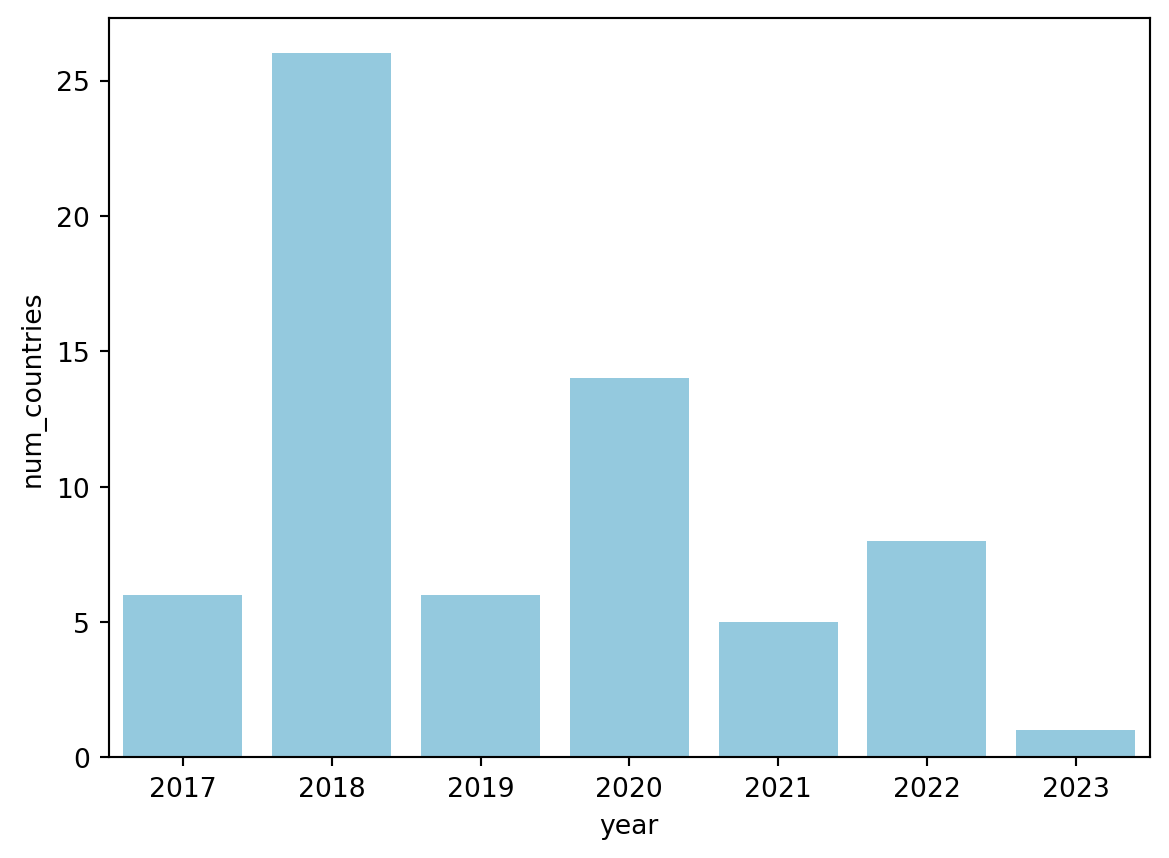

In [24]:
df_year_country = (
    df_clean.groupby("year", observed=False)["country"]
    .nunique()
    .reset_index(name="num_countries")
)
sns.barplot(data=df_year_country, x="year", y="num_countries", color="skyblue")

The majority of countries were surveyed in 2018 (26 countries), making it the dominant year in the dataset. 
This confirms the earlier point that while the wave spans 2017–2022, countries are not surveyed every year — each country is surveyed exactly 
once per wave, at different points in time.

## To check if there is any extreme dominance of any country

In [25]:
df_processed["country_name"].value_counts().head(10)

country_name
Canada            3982
Indonesia         3161
China             2945
United States     2487
Turkey            2285
Hong Kong         2035
Bolivia           1959
Singapore         1933
United Kingdom    1926
Pakistan          1841
Name: count, dtype: int64

The top 10 countries account for a substantial share of responses, but no single country dominates the dataset excessively.

In [26]:
df_processed["country"].nunique()

66

The dataset includes observations from 66 countries, with relatively balanced representation across countries. 

## Group countries by their Average Life Satisfaction


In [27]:
country_sat = (
    df_processed
    .groupby("country_name")["life_satisfaction"]
    .mean()
    .reset_index()
    .assign(satisfaction_level=lambda x: pd.cut(
        x["life_satisfaction"],
        bins=[0, 5, 6.5, 8, 10],
        labels=["Low (0–5)", "Medium (5–6.5)", "High (6.5–8)", "Very High (8–10)"]
    ))
)

# Count countries per level
level_counts = (
    country_sat
    .groupby("satisfaction_level", observed=False)
    .agg(
        num_countries=("country_name", "count"),
        countries=("country_name", lambda x: ", ".join(sorted(x)))
    )
)

level_counts

,num_countries,countries
satisfaction_level,,
Low (0–5),2,"Iraq, Zimbabwe"
Medium (5–6.5),10,"Egypt, Ethiopia, Greece, Iran, Kenya, Mongolia..."
High (6.5–8),48,"Andorra, Argentina, Armenia, Australia, Bangla..."
Very High (8–10),6,"Colombia, Kyrgyzstan, Mexico, Puerto Rico, Uru..."


The data shows that many cluster in the "High" satisfaction tier, suggesting a global tendency toward positive well-being. We can do plots later with this table.

## Creating Age Groups


In [28]:
age_bins = [16, 30, 45, 65, 90]
age_labels = ["Youth", "Young Adult", "Middle Age", "Senior"]

df_processed = (
    df_processed
    .assign(
        age_group = lambda x: pd.cut(x['age'], bins=age_bins, labels=age_labels),        
        ls_relative = lambda x: x['life_satisfaction'] - x.groupby('country_name')['life_satisfaction'].transform('mean')
    )
)
df_processed.head()

,life_satisfaction,income,health,freedom,financial_satisfaction,education,year,country,age,sex,marital_status,country_name,age_group,ls_relative
0,10.0,5.0,3,10.0,5.0,3.0,2018,20,60.0,2,1,Andorra,Middle Age,2.424829
1,9.0,9.0,5,9.0,9.0,7.0,2018,20,47.0,1,2,Andorra,Middle Age,1.424829
2,9.0,5.0,5,9.0,8.0,7.0,2018,20,48.0,1,4,Andorra,Middle Age,1.424829
3,8.0,4.0,4,9.0,6.0,2.0,2018,20,62.0,2,2,Andorra,Middle Age,0.424829
4,7.0,4.0,4,8.0,7.0,2.0,2018,20,49.0,1,2,Andorra,Middle Age,-0.575171


In [29]:
df_processed.describe()

,life_satisfaction,income,health,freedom,financial_satisfaction,education,age,ls_relative
count,91295.000000,91295.000000,91295.000000,91295.000000,91295.000000,91295.000000,91295.000000,9.129500e+04
mean,7.061789,4.913314,3.812673,7.216496,6.197963,3.561247,42.995684,2.334879e-17
std,2.237807,2.087301,0.874357,2.257519,2.424741,2.020144,16.405195,2.111261e+00
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,16.000000,-7.431319e+00
25%,6.000000,4.000000,3.000000,6.000000,5.000000,2.000000,29.000000,-1.223112e+00
50%,7.000000,5.000000,4.000000,8.000000,6.000000,3.000000,41.000000,3.162752e-01
75%,9.000000,6.000000,4.000000,9.000000,8.000000,6.000000,55.000000,1.518600e+00
max,10.000000,10.000000,5.000000,10.000000,10.000000,8.000000,103.000000,5.530802e+00


## Steps performed in Data Processing Section

To prepare the data for analysis, we created the following new variables:

**`country_name`** — mapped from numeric country codes to readable country names using the WVS codebook, with four unmapped codes 
(Maldives, Serbia, Macao, Northern Ireland) resolved manually.  

**`satisfaction_level`** — countries grouped into four happiness tiers (Low, Medium, High, Very High) based on their average life satisfaction 
score.

**`age_group`** — respondents binned into four life-stage categories (Youth, Young Adult, Middle Age, Senior).

**`ls_relative`** — each respondent's life satisfaction demeaned by their country's mean, allowing within-country comparisons across age 
groups.

# Exploratory Data Analysis

## How does Financial Satisfaction shape Life Satisfaction?

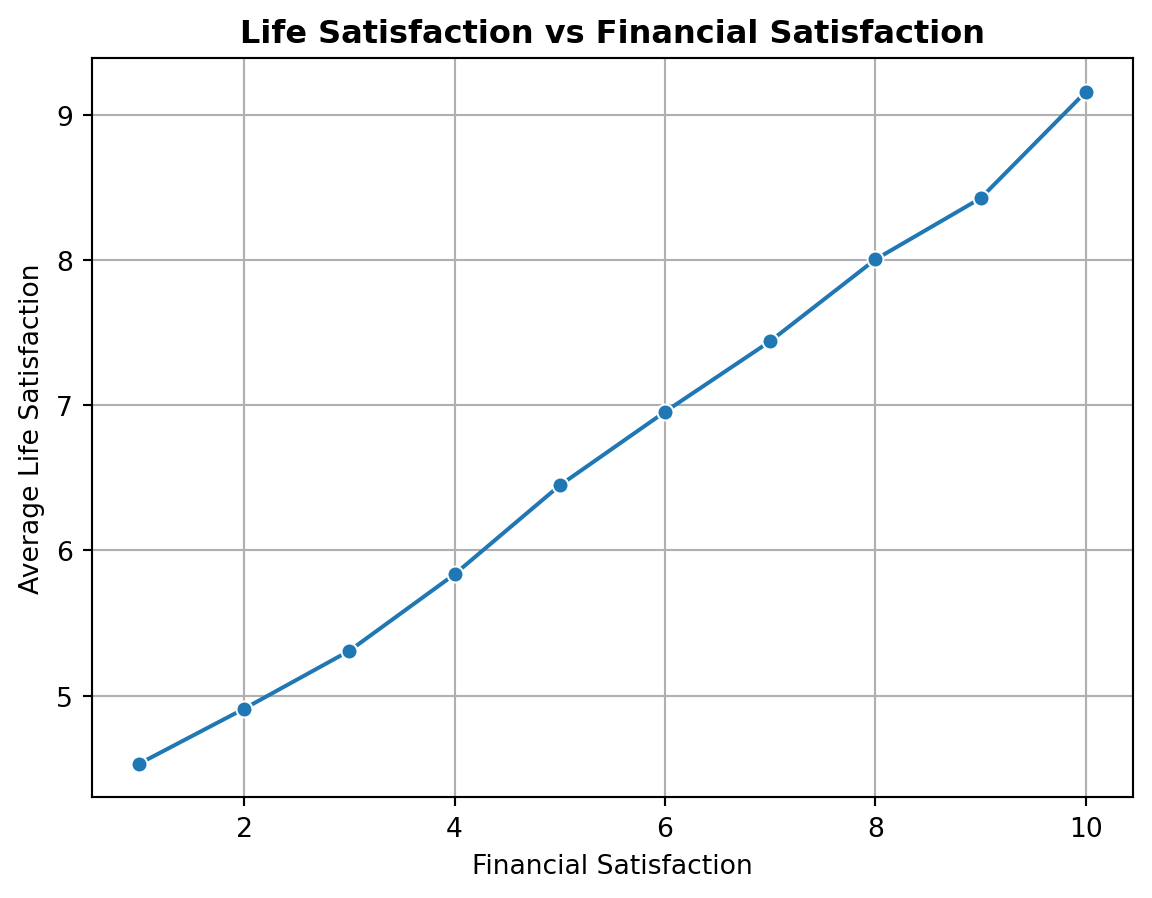

In [30]:
df_plot = df_processed.groupby("financial_satisfaction", as_index=False)["life_satisfaction"].mean()

# Plot
sns.lineplot(
    data=df_plot,
    x="financial_satisfaction",
    y="life_satisfaction",
    marker="o"
)

plt.title("Life Satisfaction vs Financial Satisfaction", fontweight="bold")
plt.xlabel("Financial Satisfaction")
plt.ylabel("Average Life Satisfaction")
plt.grid()
plt.show()

The observed association suggests that as individuals’ perceived financial security and satisfaction increase, their overall life satisfaction rises in a linear and consistent manner.

## How does Health shape Life Satisfaction?

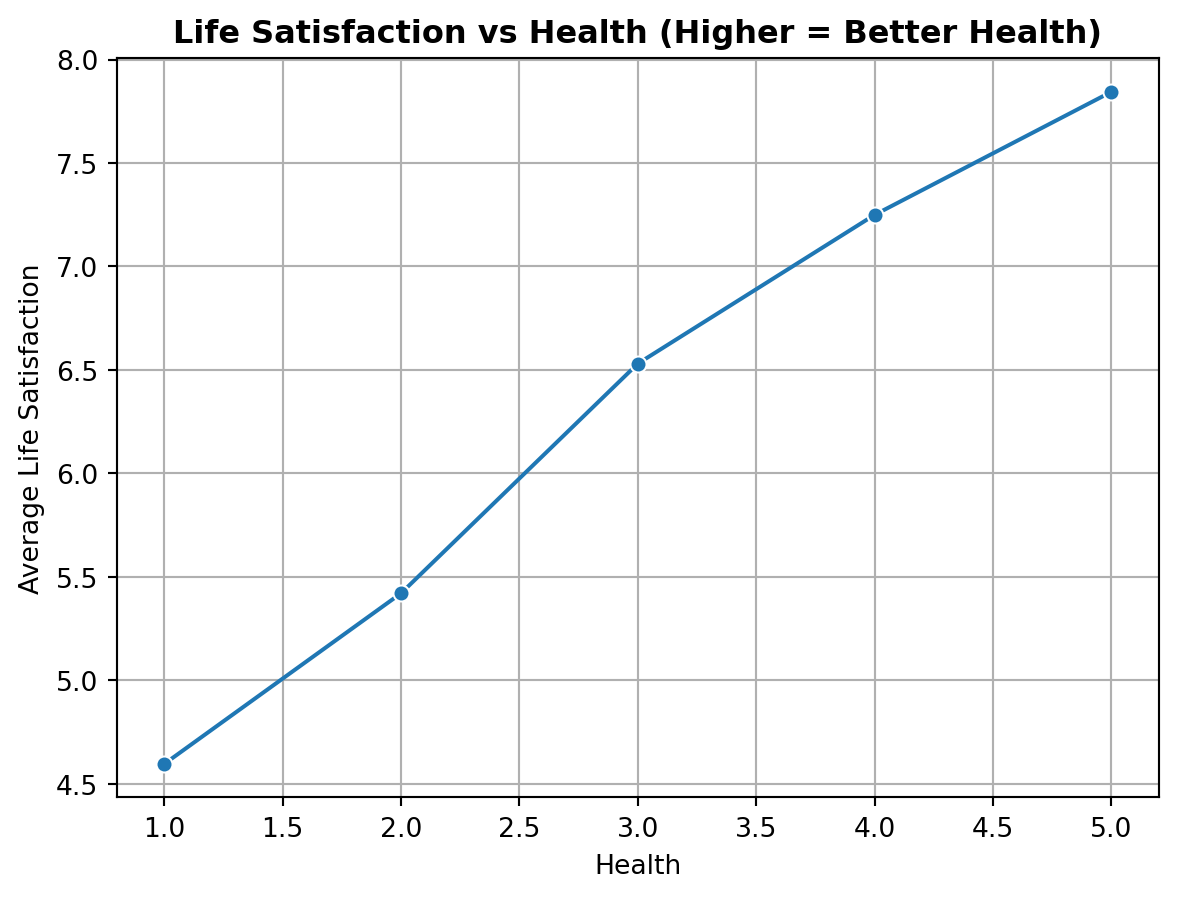

In [31]:
sns.lineplot(
    data=df_processed,
    x="health",
    y="life_satisfaction",
    estimator="mean",
    marker="o",
    errorbar=None
)

plt.title("Life Satisfaction vs Health (Higher = Better Health)", fontweight="bold")
plt.xlabel("Health")
plt.ylabel("Average Life Satisfaction")
plt.grid()
plt.show()

This graph shows that as Physical Health improves (from 1 to 5), Life Satisfaction follows in a nearly straight upward line.

## How is Life Satisfaction distributed across our sample?

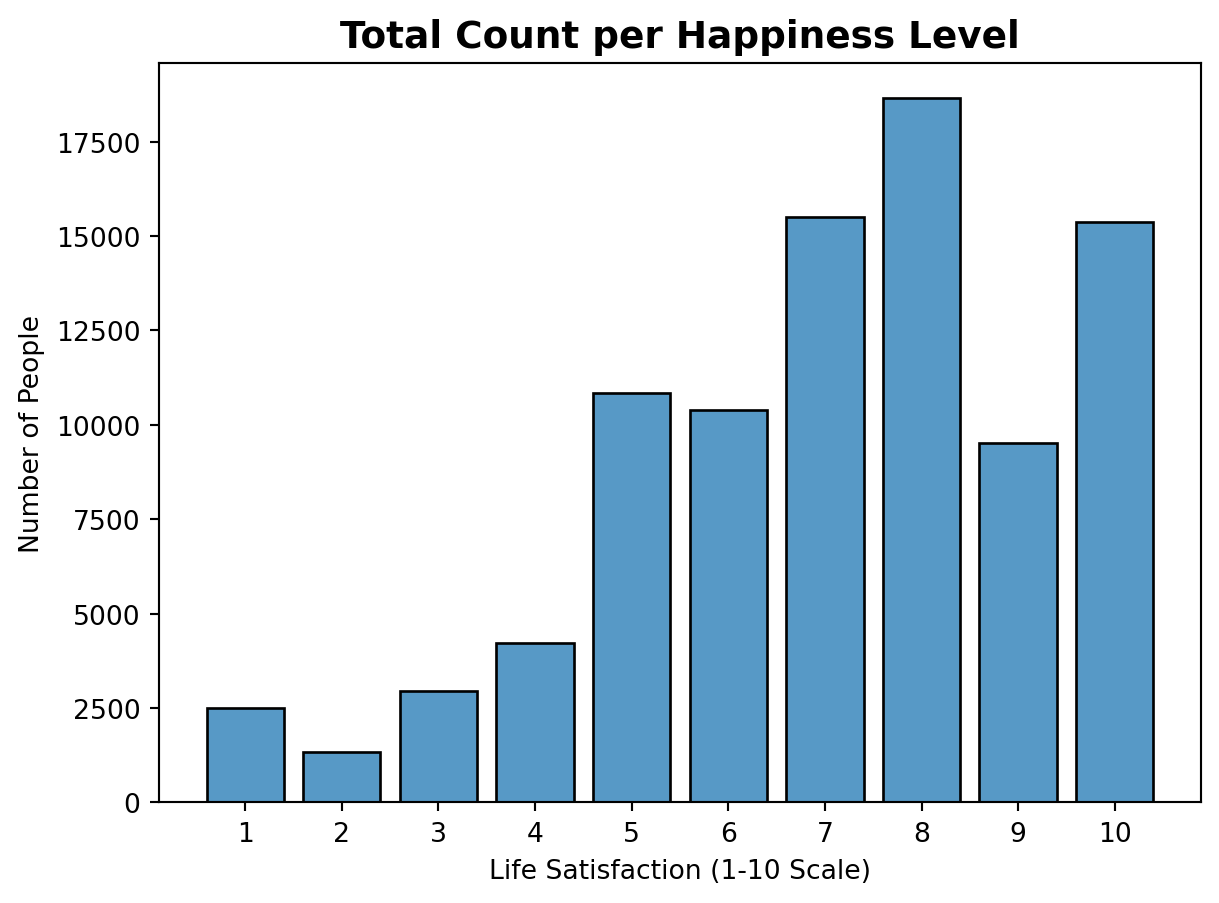

In [32]:
sns.histplot(
    data=df_processed,
    x="life_satisfaction",
    discrete=True,      
    shrink=0.8         
)

plt.title("Total Count per Happiness Level", fontsize=14, fontweight="bold")
plt.xlabel("Life Satisfaction (1-10 Scale)")
plt.ylabel("Number of People")
plt.xticks(range(1, 11))
plt.show()

Mostly People are in happier range. Very few people seems to be unhappier.

## Global Happiness Tiers: How Many Countries Sit at Each Level?

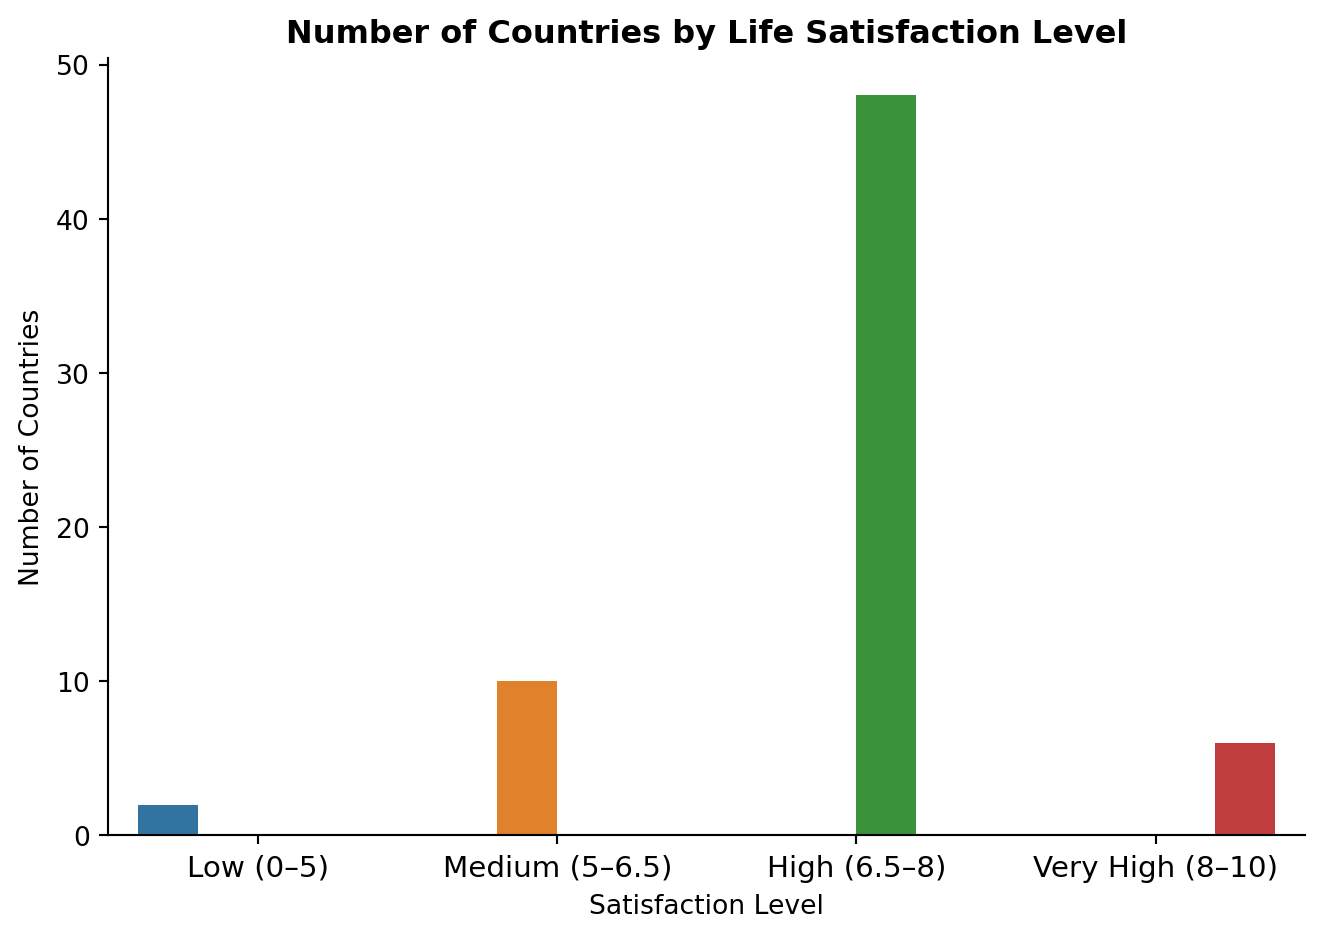

In [33]:
sns.barplot(
    level_counts,
    x="satisfaction_level",
    y="num_countries",
    hue="satisfaction_level"
)
plt.title("Number of Countries by Life Satisfaction Level", fontweight="bold")
plt.xlabel("Satisfaction Level")
plt.ylabel("Number of Countries")
plt.xticks(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

The chart shows the vast majority of countries cluster in the "High" satisfaction tier, indicating that moderate-to-high life satisfaction is the global norm within this dataset.

## Which countries Fall into which tier?

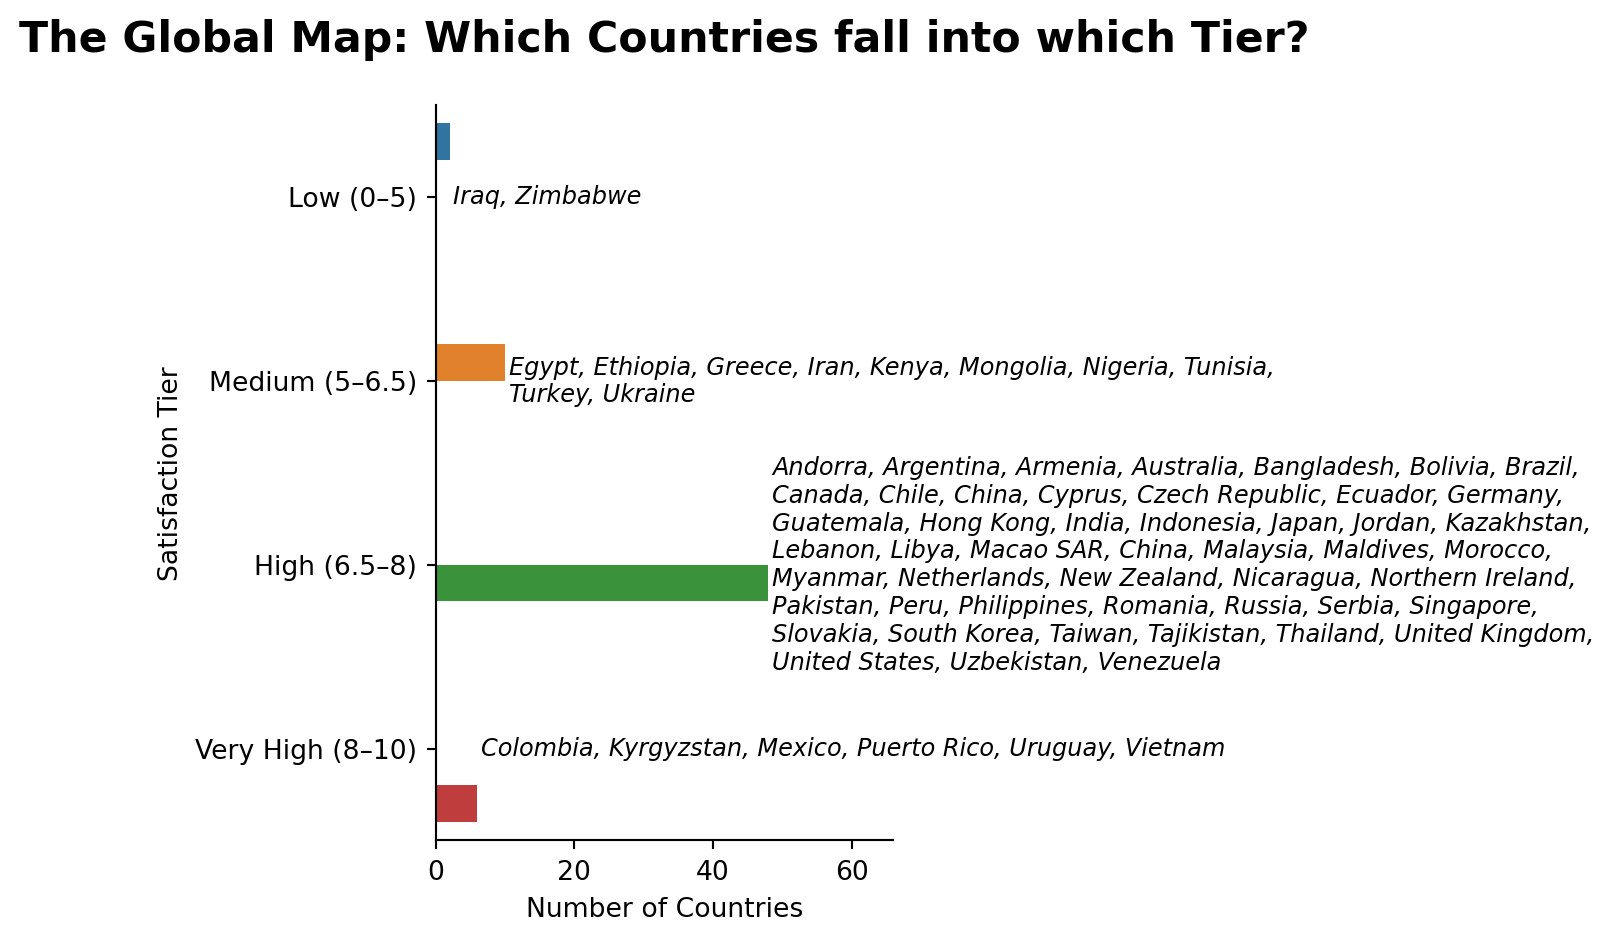

In [34]:
plot_data = level_counts.reset_index()
ax = sns.barplot(
    data=plot_data, 
    y="satisfaction_level", 
    x="num_countries", 
    hue="satisfaction_level",
    legend=False
)

# Add the list of countries next to each bar
for i, row in plot_data.iterrows():
    country_list = row['countries']    
    wrapped_text = "\n".join(textwrap.wrap(country_list, width=70))
    
    # Place the text slightly to the right of the bar
    plt.text(
        row['num_countries'] + 0.5,
        i,                          
        wrapped_text, 
        va='center', 
        fontsize=9, 
        fontstyle='italic'
    )

plt.title("The Global Map: Which Countries fall into which Tier?", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Number of Countries")
plt.ylabel("Satisfaction Tier")
plt.xlim(0, 66)
sns.despine()
plt.tight_layout()
plt.show()

## How is Life Satisfaction geographically distributed across the globe?

In [35]:
fig = px.choropleth(
    country_sat,
    locations="country_name",
    locationmode="country names",
    color="satisfaction_level",
    color_discrete_map={
        "Low (0–5)": "#d73027",
        "Medium (5–6.5)": "#fee08b",
        "High (6.5–8)": "#a6d96a",
        "Very High (8–10)": "#1a9850"
    },
    title="Global Life Satisfaction Tiers (WVS 2017–2022)",
    category_orders={"satisfaction_level": ["Low (0–5)", "Medium (5–6.5)", "High (6.5–8)", "Very High (8–10)"]}
)

fig.update_layout(
    legend_title="Satisfaction Tier",
    geo=dict(showframe=False, showcoastlines=True),
    width=1200,
    height=650,
    title_font_size=18
)

fig.show()

C:\Users\mrina\AppData\Local\Temp\ipykernel_15708\2763789798.py:1: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


## How are Life Satisfaction and its key socio-economic determinants correlated?

<Axes: >

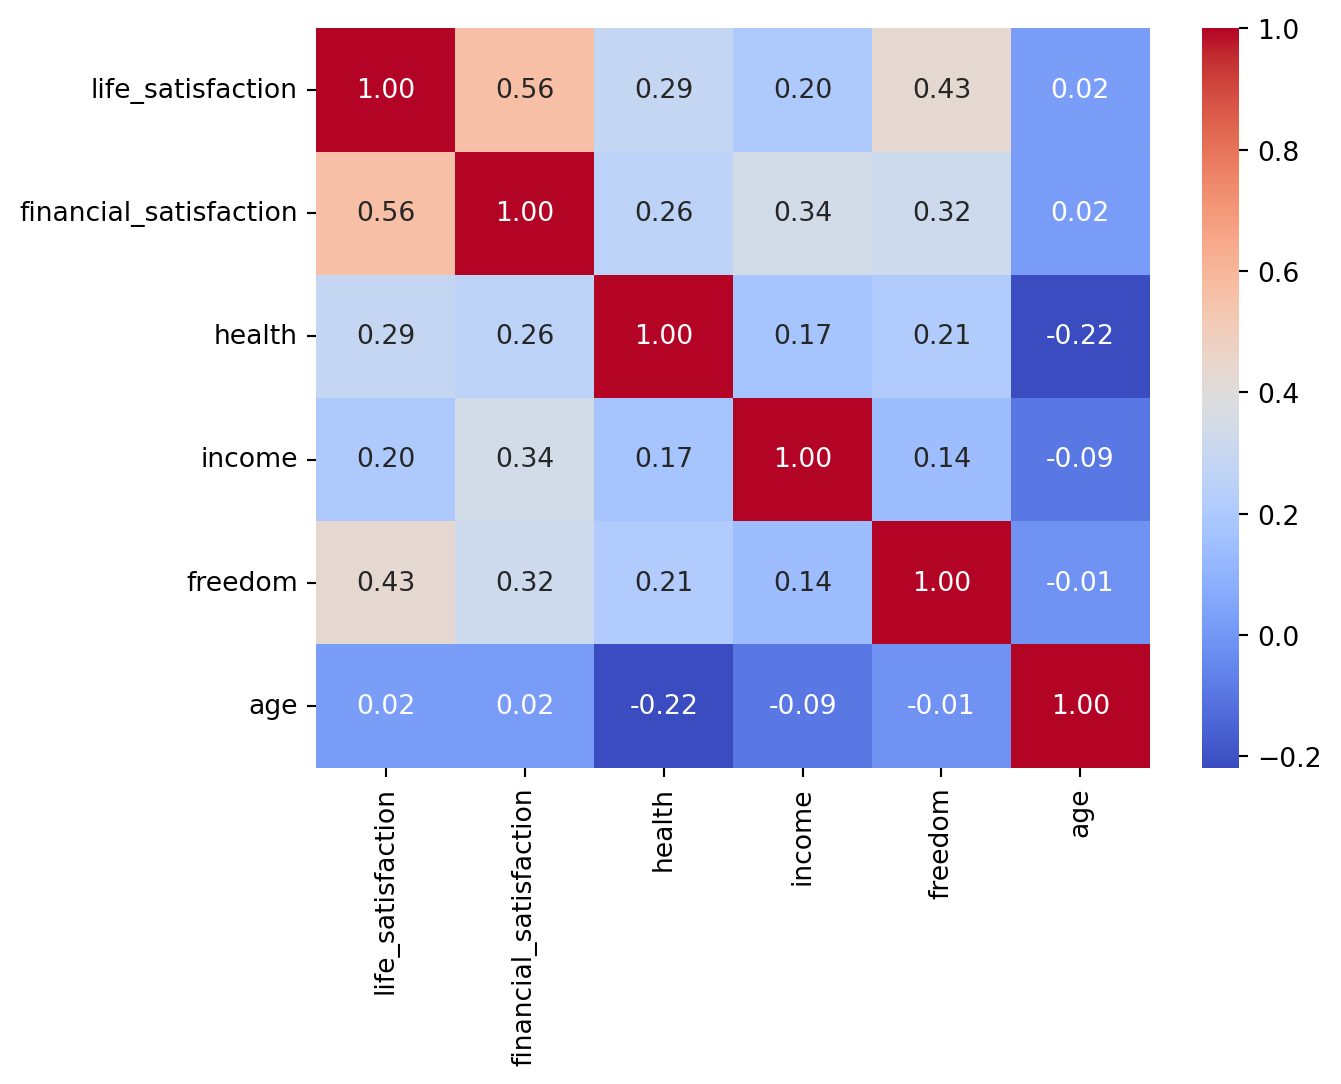

In [36]:
sns.heatmap(
    df_processed[["life_satisfaction", "financial_satisfaction", "health", "income", "freedom", "age"]].corr(),
    annot=True, cmap="coolwarm", fmt=".2f"
)

The correlation matrix reveals that financial satisfaction has the strongest bivariate association with life satisfaction (r = 0.56), followed by freedom (0.43), health (0.29), and income (0.20).

## How Life satisfaction changes across different ages within country?

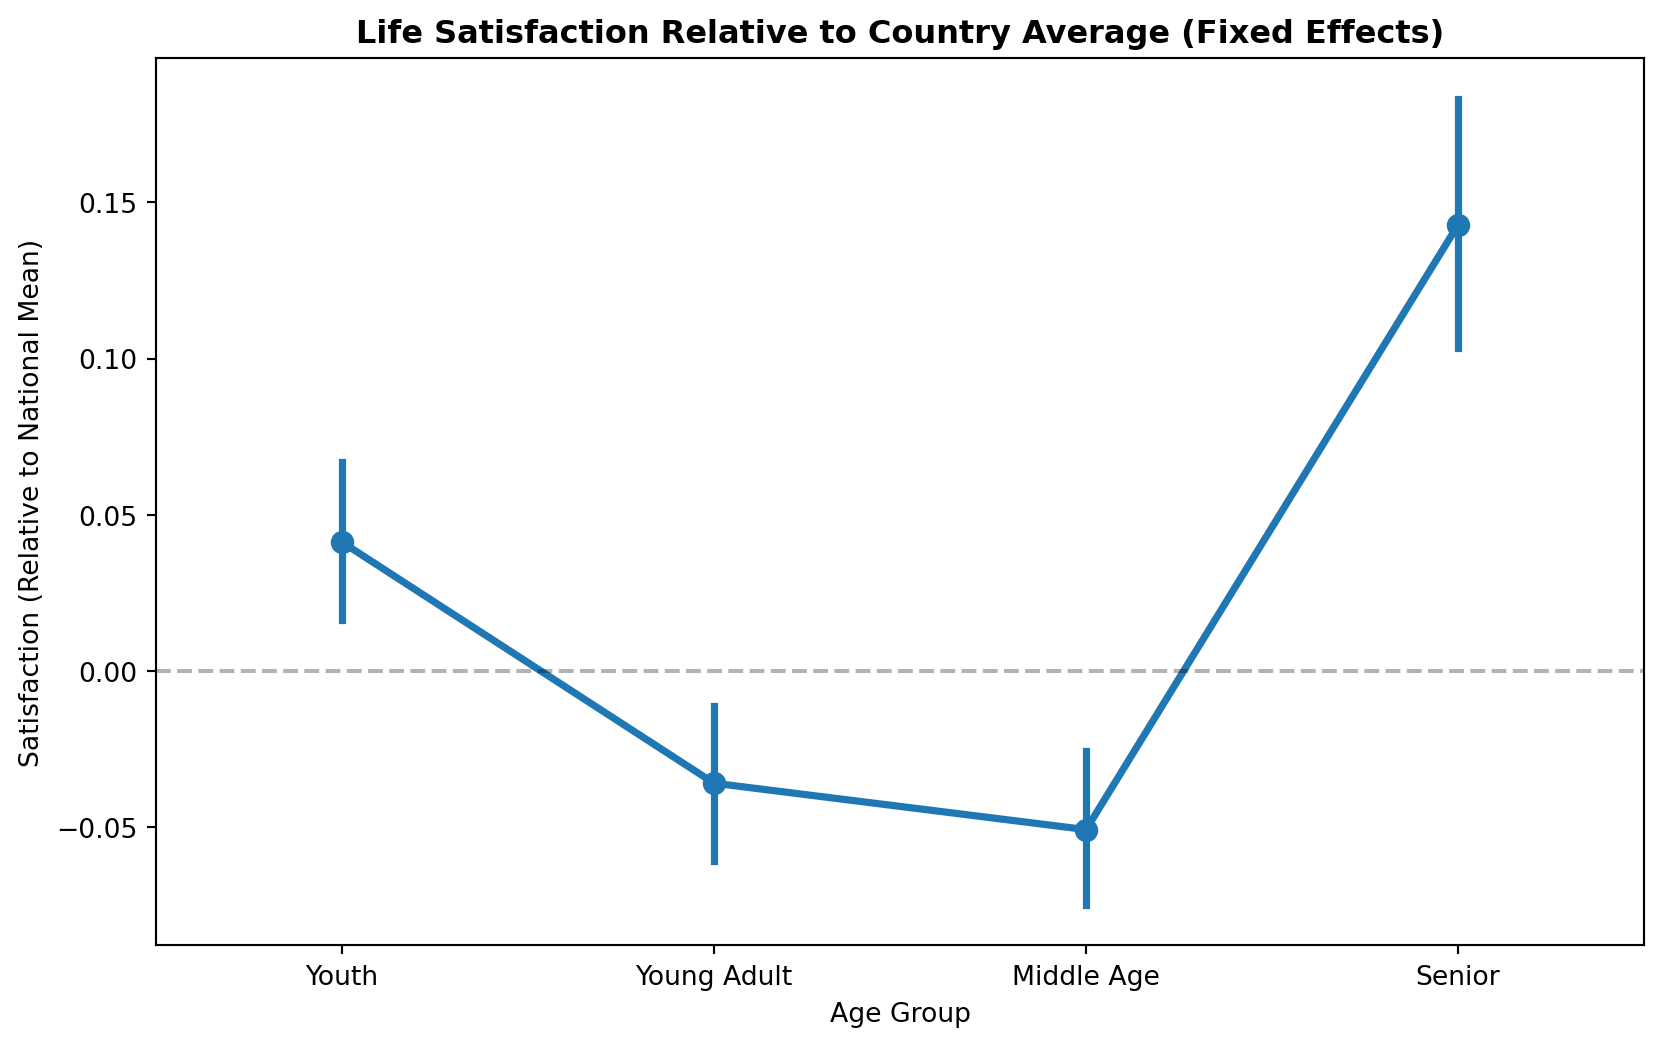

In [37]:
plt.figure(figsize=(10, 6))
sns.pointplot(data=df_processed, x="age_group", y="ls_relative")
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.title("Life Satisfaction Relative to Country Average (Fixed Effects)", fontweight="bold")
plt.ylabel("Satisfaction (Relative to National Mean)")
plt.xlabel("Age Group")
plt.show()

While life satisfaction dips during the working years (Youth to Middle Age), it recovers significantly in the Senior years. 

## Within the same country, how do financial satisfaction, physical health, and income group compare as predictors of overall life satisfaction?

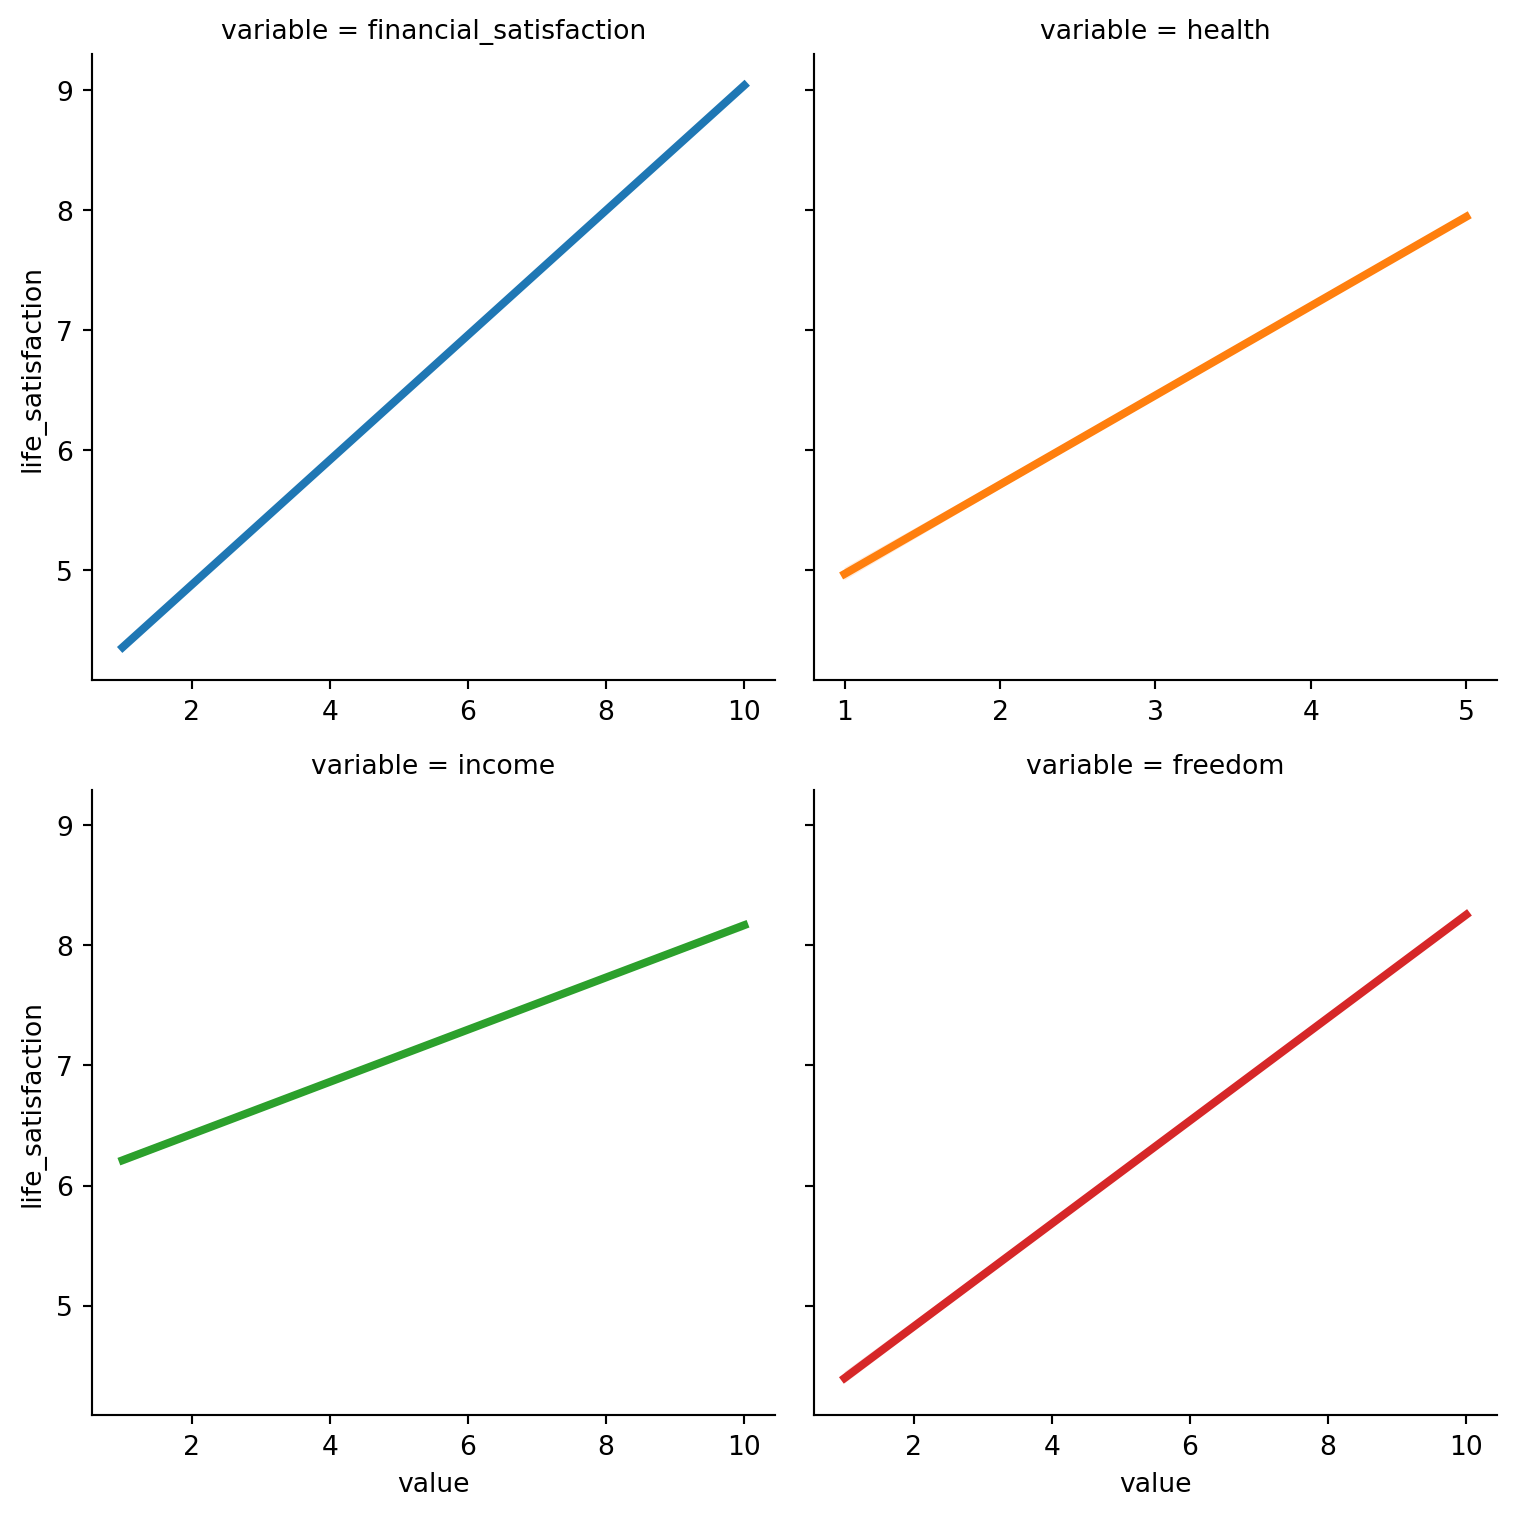

In [38]:
# Reshape
df_long = df_processed.melt(
    id_vars="life_satisfaction",
    value_vars=["financial_satisfaction", "health", "income", "freedom"]
)

g = sns.FacetGrid(
    df_long,
    col="variable",
    hue="variable",
    sharex=False,
    height=4,
    col_wrap=2   
)

g.map(
    sns.regplot,
    "value",
    "life_satisfaction",
    scatter=False,
    line_kws={"lw": 3}
)

plt.show()

Regplot analysis shows that financial satisfaction has the steepest positive association with life satisfaction among the three predictors, while income shows the flattest slope.

## In which countries is Financial Satisfaction most strongly (and weakly) related to life satisfaction?

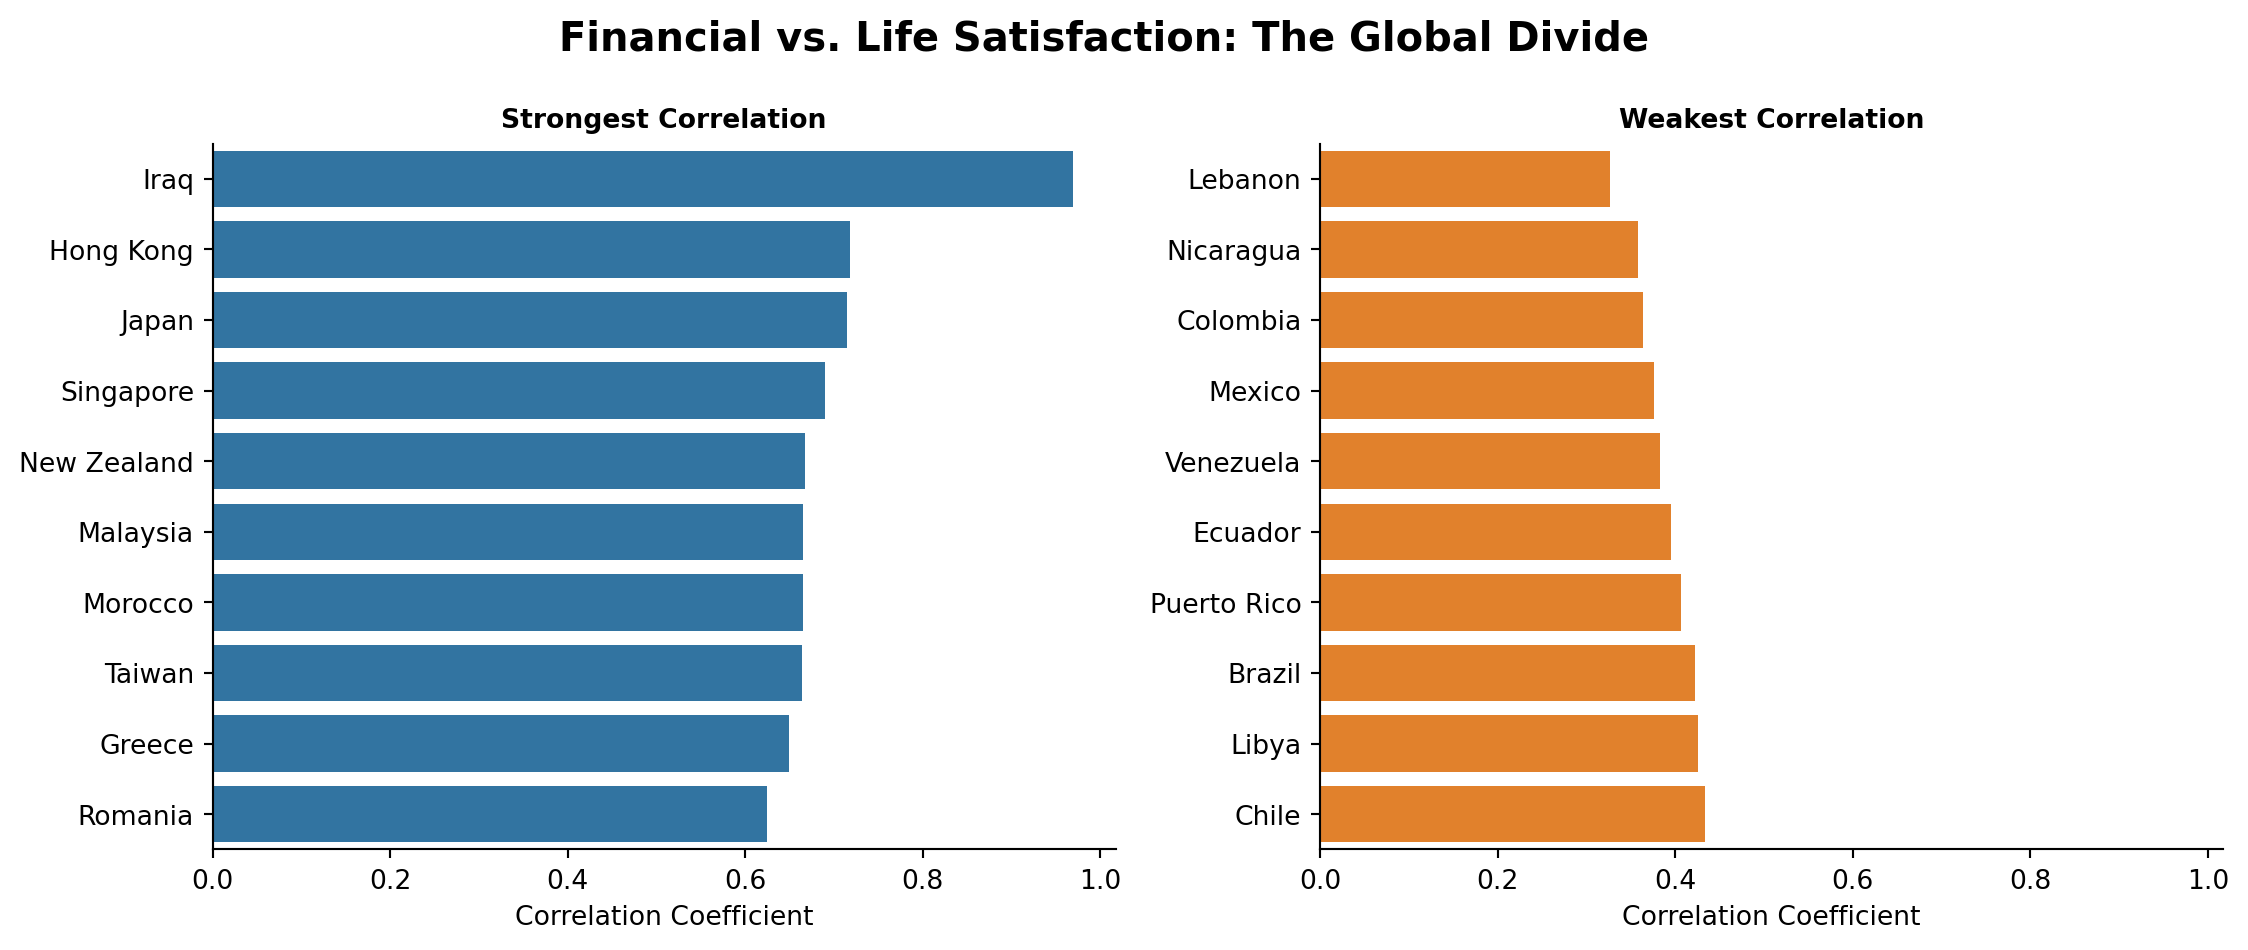

In [39]:
country_corr = (
    df_processed.groupby("country_name", observed=False)
    .apply(lambda x: x["financial_satisfaction"].corr(x["life_satisfaction"]), include_groups=False)
    .reset_index(name="correlation")
)

top_10 = country_corr.nlargest(10, "correlation").assign(Group="Strongest Correlation")
bottom_10 = country_corr.nsmallest(10, "correlation").assign(Group="Weakest Correlation")
plot_df = pd.concat([top_10, bottom_10])

g = sns.FacetGrid(plot_df, col="Group", hue="Group", col_wrap=2, 
                  height=5, aspect=1.2, sharey=False, 
                  )

g.map_dataframe(sns.barplot, x="correlation", y="country_name")

g.set_titles("{col_name}", fontweight="bold")
g.set_axis_labels("Correlation Coefficient", "")
plt.subplots_adjust(top=0.85)
g.fig.suptitle("Financial vs. Life Satisfaction: The Global Divide", fontsize=15, fontweight="bold")

plt.show()

 **Financial satisfaction's importance is not universal — it depends on where you are**

- In **crisis/materialist countries** → financial satisfaction is almost the ONLY thing that matters
- In **Latin American/community-oriented countries** → financial satisfaction matters but social factors matter more

**The country-level correlation analysis reveals substantial heterogeneity in how strongly financial satisfaction predicts life satisfaction across nations.**     

- In economically distressed or conflict-affected countries such as Iraq, Greece, and Romania, financial satisfaction is nearly the sole determinant of life satisfaction — consistent with Maslow's hierarchy where basic security needs dominate.
  
- Conversely, in Latin American countries such as Puerto Rico, Colombia, and Mexico, the correlation is significantly weaker,  suggesting that strong social bonds and cultural optimism buffer the impact of financial dissatisfaction on overall wellbeing.

- This heterogeneity underscores the importance of country fixed effects in the regression model.

## How does subjective wellbeing (Financial satisfaction and Life satisfaction) vary across countries at different levels of economic development?

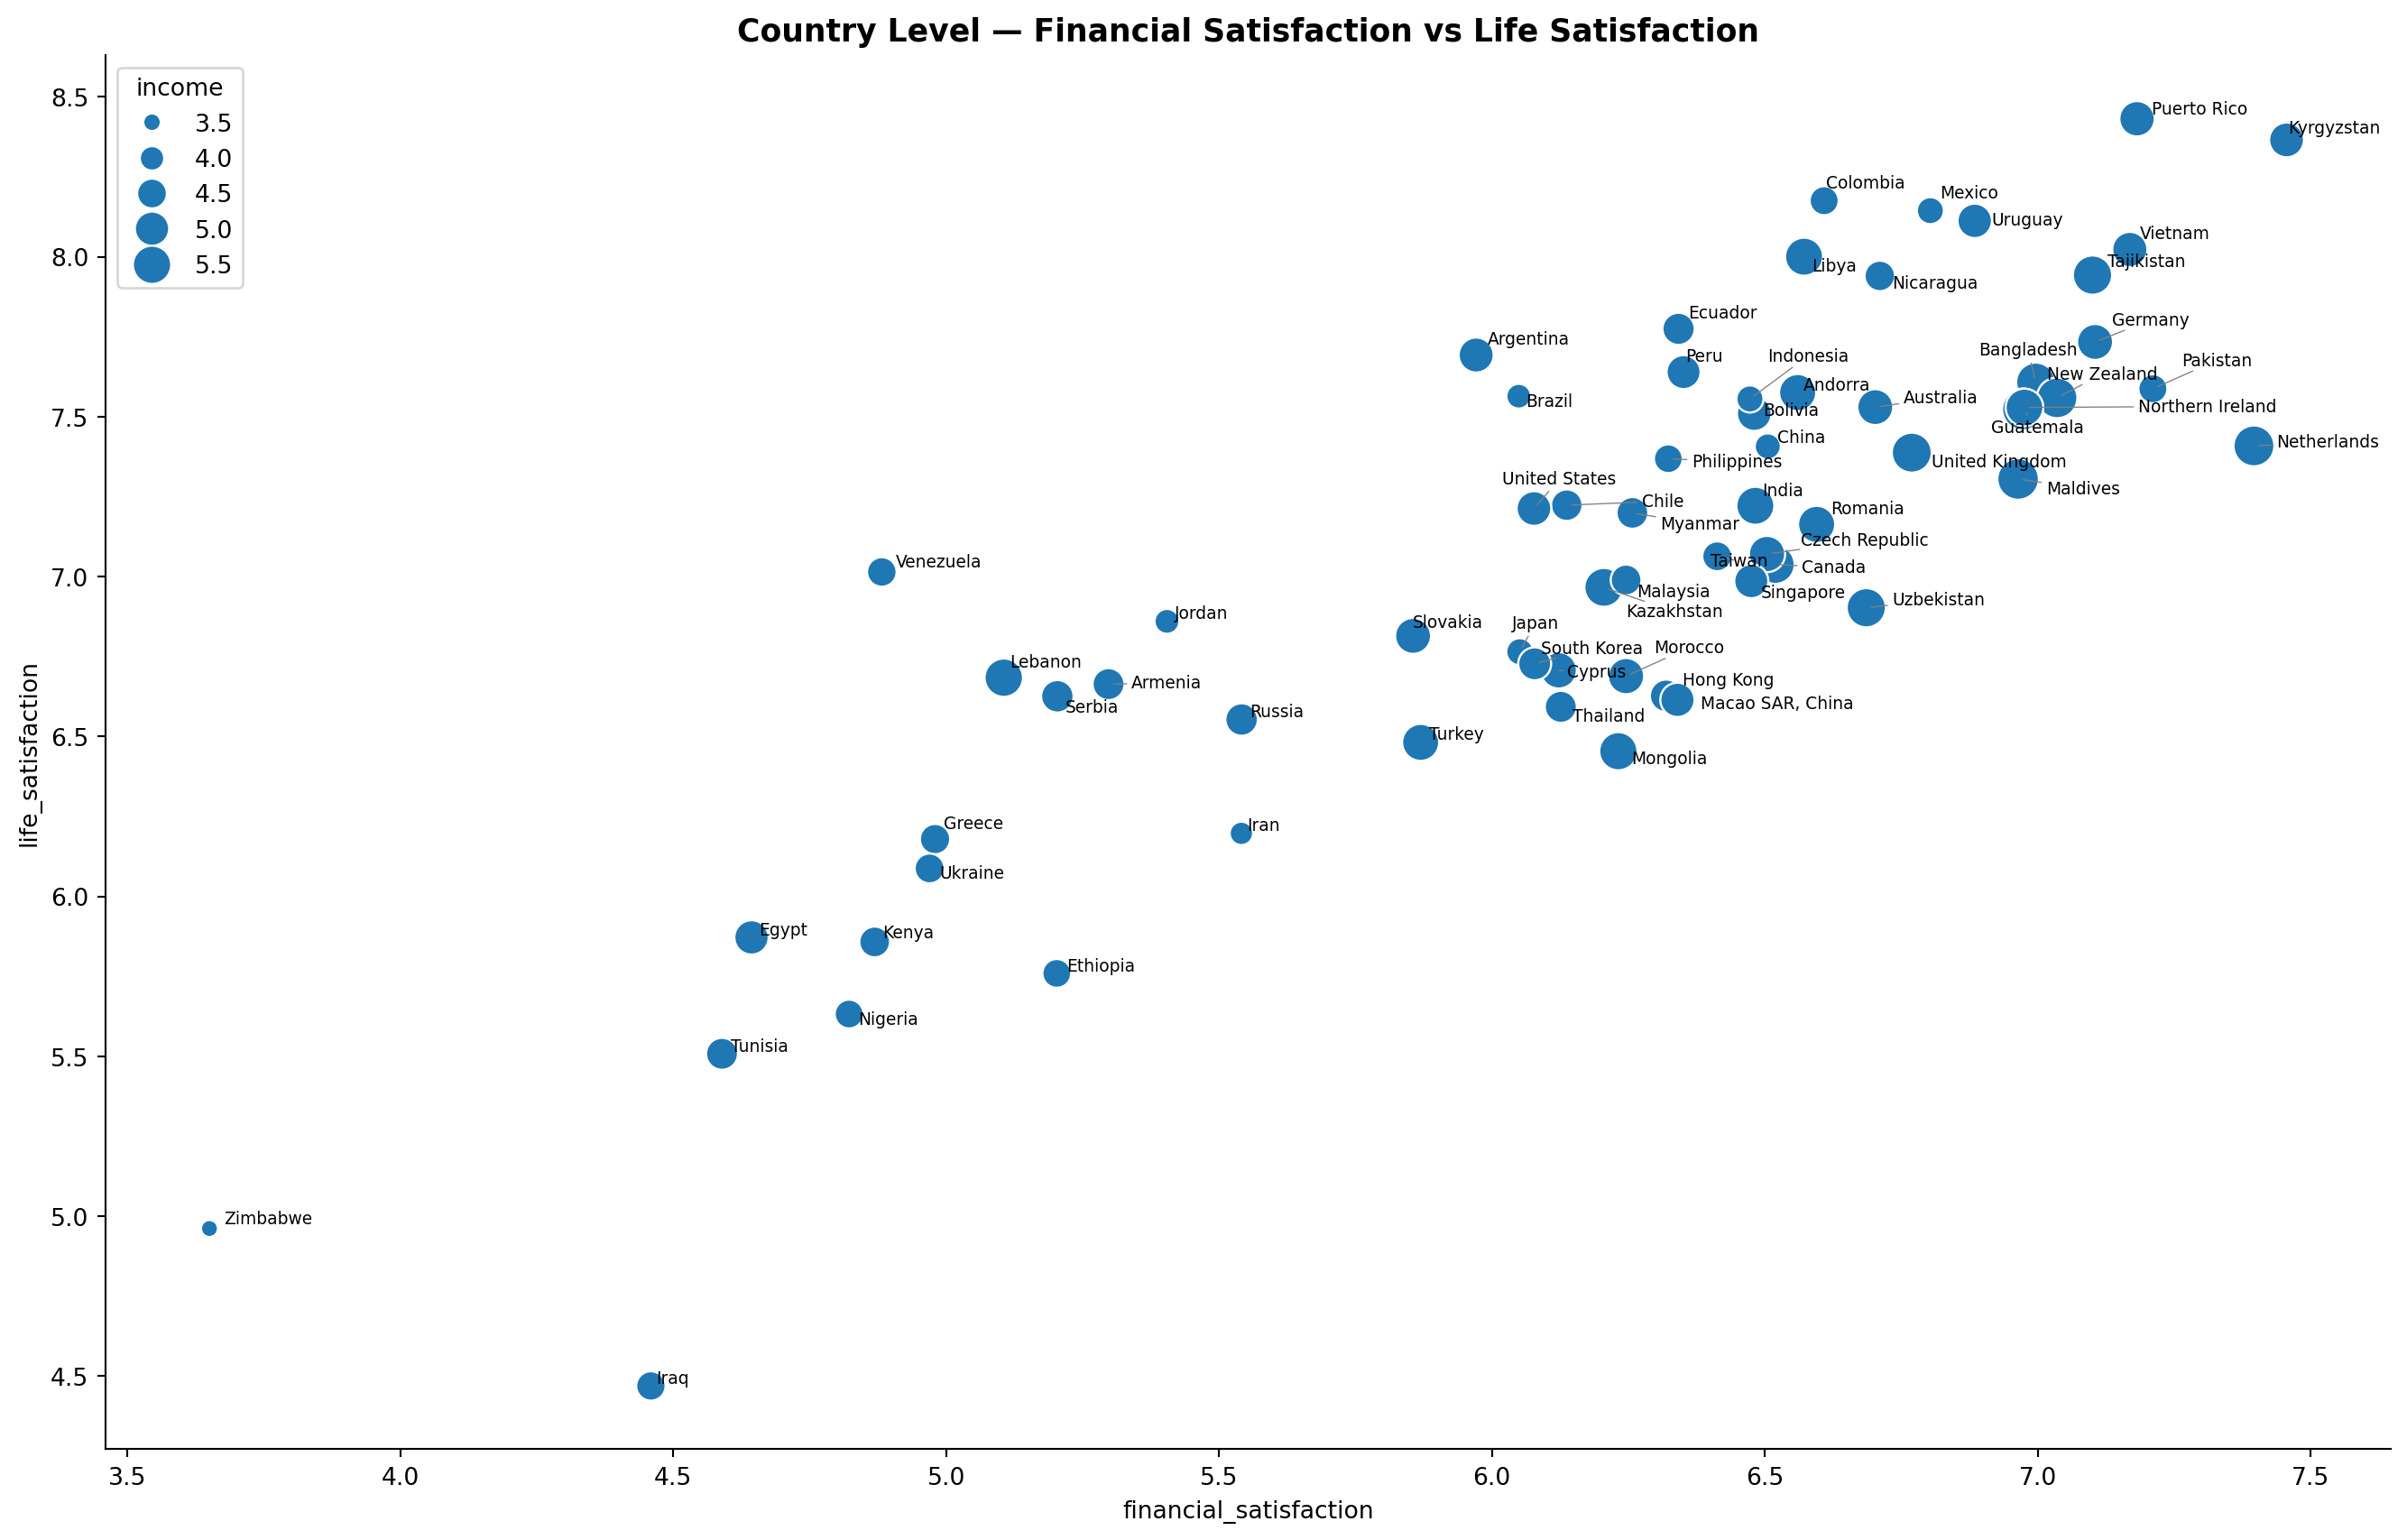

In [40]:
country_avg = (
    df_processed
    .groupby("country_name")[["life_satisfaction", "financial_satisfaction", "income"]]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 9))

sns.scatterplot(
    data=country_avg,
    x="financial_satisfaction",
    y="life_satisfaction",
    size="income",
    sizes=(50, 300),
    ax=ax
)

texts = [
    ax.annotate(row["country_name"],
                (row["financial_satisfaction"], row["life_satisfaction"]),
                fontsize=7)
    for _, row in country_avg.iterrows()
]

adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

ax.set_title("Country Level — Financial Satisfaction vs Life Satisfaction", 
             fontweight="bold", fontsize=13)
sns.despine()
plt.tight_layout()
plt.show()

- The scatter plot reveals a clear positive relationship between financial satisfaction and life satisfaction at the country level — countries where 
people feel more financially secure tend to report higher life satisfaction overall. Bubble size represents average income, which does not strongly 
track with life satisfaction, reinforcing our core finding that subjective financial security matters more than objective income.  

- Several patterns stand out. Latin American countries (Puerto Rico, Colombia, Mexico, Uruguay, Nicaragua) cluster in the upper right — reporting high life satisfaction relative to their income levels, suggesting that cultural factors such as social connectedness and optimism play an important mediating role.   

- At the other extreme, Iraq and Zimbabwe sit in the lower left — low financial satisfaction and low life satisfaction — consistent with the literature on conflict and economic instability driving wellbeing down.

- Notably, high-income Western countries like the Netherlands, Canada, and Australia sit in the middle-to-upper right but are not the happiest — 
suggesting that beyond a certain level of financial security, additional income yields diminishing returns to life satisfaction, consistent with the 
Easterlin Paradox.

## Did Life satisfaction drop during COVID years (2020–2021)?

In [41]:
df_processed["covid"] = df_processed["year"].astype(str).isin(["2020", "2021"]).astype(int)

(
    smf.ols(
        "life_satisfaction ~ financial_satisfaction + health + income + C(covid)",
        data=df_processed
    )
    .fit()
    .summary(slim=True)
)

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      life_satisfaction   R-squared:                       0.341
Model:                            OLS   Adj. R-squared:                  0.341
No. Observations:               91295   F-statistic:                 1.181e+04
Covariance Type:            nonrobust   Prob (F-statistic):               0.00
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  2.5993      0.030     87.991      0.000       2.541       2.657
C(covid)[T.1]             -0.1524      0.013    -11.460      0.000      -0.179      -0.126
financial_satisfaction     0.4829      0.003    178.727      0.000       0.478       0.488
health                     0.4001      0.007     55.980      0.000       0.386       0.414
income                    -0.0025      0.003     -0.809      0.419      -0.009       0.004
==========================================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

During the COVID period (2020–2021), life satisfaction decreased significantly by about 0.15 points, even after controlling for individual economic and health conditions

## Does the effect of Financial satisfaction on life satisfaction differ by sex?

In [42]:
model = smf.ols(
    "life_satisfaction ~ financial_satisfaction * C(sex)",
    data=df_processed
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      life_satisfaction   R-squared:                       0.318
Model:                            OLS   Adj. R-squared:                  0.318
Method:                 Least Squares   F-statistic:                 1.416e+04
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:50:23   Log-Likelihood:            -1.8564e+05
No. Observations:               91295   AIC:                         3.713e+05
Df Residuals:                   91291   BIC:                         3.713e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

**Financial satisfaction** is a marginally stronger predictor of life satisfaction for men than for women. 

However, the magnitude of this difference is economically negligible. Women report higher baseline life satisfaction than men, consistent with global wellbeing literature suggesting women draw satisfaction from more diverse social and relational sources beyond financial wellbeing.

# Regression Analysis

We estimate a series of nine OLS regression models, each building on the previous by adding variables incrementally. This stepwise approach 
allows us to observe how coefficients change as controls are added, and whether financial satisfaction remains the dominant predictor 
throughout. The dependent variable in all models is `life_satisfaction` (1–10 scale). 

Model 7 — with full demographic, social, and country fixed effects — is our main specification. Model 8 tests interaction effects, and Model 9 serves as a robustness check by dropping income entirely to verify that financial satisfaction's effect is not driven by its correlation with income.

In [43]:
# (1) BASE MODEL
# Purpose: baseline relationship between financial satisfaction and life satisfaction

mdl1 = smf.ols(
    "life_satisfaction ~ financial_satisfaction",
    data=df_processed
).fit()

# (2) ADD HEALTH
# Purpose: check if health explains additional variation
mdl2 = smf.ols(
    "life_satisfaction ~ financial_satisfaction + health",
    data=df_processed
).fit()

# (3) ADD INCOME
# Purpose: test economic resources effect beyond perceived satisfaction
mdl3 = smf.ols(
    "life_satisfaction ~ financial_satisfaction + health + income",
    data=df_processed
).fit()

# (4) ADD FREEDOM
# Purpose: include subjective autonomy/choice effects
mdl4 = smf.ols(
    "life_satisfaction ~ financial_satisfaction + health + income + freedom",
    data=df_processed
).fit()

# (5) DEMOGRAPHICS
# Purpose: control for age and gender differences
mdl5 = smf.ols(
    "life_satisfaction ~ financial_satisfaction + health + income + freedom + age + C(sex)",
    data=df_processed
).fit()

# (6) SOCIAL CONTROLS
# Purpose: add education and marital status (life structure effects)
mdl6 = smf.ols(
    "life_satisfaction ~ financial_satisfaction + health + income + freedom + age + C(sex) + education + C(marital_status)",
    data=df_processed
).fit()

# (7) COUNTRY FIXED EFFECTS (MAIN MODEL)
# Purpose: control for cultural/institutional differences across countries
mdl7 = smf.ols(
    "life_satisfaction ~ financial_satisfaction + health + income + freedom + age + "
    "C(sex) + education + C(marital_status) + C(country_name)",
    data=df_processed
).fit()

# (8) INTERACTION MODEL
# Purpose: check whether relationships depend on context
mdl8 = smf.ols(
    "life_satisfaction ~ financial_satisfaction + health + income + freedom + age + "
    "C(sex) + education + year + C(marital_status) + C(country_name) + "
    "health:age + income:freedom + health:financial_satisfaction",
    data=df_processed
).fit()

# (9) ROBUSTNESS CHECK (WITHOUT INCOME)
# Purpose: test if income is driving results or not
mdl9 = smf.ols(
    "life_satisfaction ~ financial_satisfaction + health + freedom + age + "
    "C(sex) + education + year + C(marital_status) + C(country_name) + "
    "health:age + health:financial_satisfaction",
    data=df_processed
).fit()

## Print the summary

In [44]:
results = summary_col(
    [mdl1, mdl2, mdl3, mdl4, mdl5, mdl6, mdl7, mdl8, mdl9],

    model_names=[
        "Base",
        "+Health",
        "+Income",
        "+Freedom",
        "+Demographics",
        "+Social Controls",
        "Country Fixed Effects",
        "Interactions",
        " Without Income"
    ],

    stars=True,

    regressor_order=[
        "Intercept",
        "financial_satisfaction",
        "health",
        "income",
        "freedom",
        "age",
        "C(sex)[T.2]",
        "education",
        "year",
        "C(marital_status)[T.2]",
        "C(marital_status)[T.3]",
        "C(marital_status)[T.4]",
        "C(marital_status)[T.5]",
        "C(marital_status)[T.6]",
        "C(country_name)",
        "health:age",
        "income:freedom",
        "health:financial_satisfaction"
    ],

    drop_omitted=True,

)
results

,Base,+Health,+Income,+Freedom,+Demographics,+Social Controls,Country Fixed Effects,Interactions,Without Income
Intercept,3.8397***,2.5449***,2.5539***,1.4707***,1.0224***,1.1097***,1.7021***,0.9284***,0.9256***
,(0.0168),(0.0284),(0.0293),(0.0301),(0.0374),(0.0403),(0.0724),(0.0917),(0.0866)
financial_satisfaction,0.5199***,0.4828***,0.4839***,0.4156***,0.4108***,0.4105***,0.3786***,0.4811***,0.4827***
,(0.0025),(0.0026),(0.0027),(0.0027),(0.0027),(0.0027),(0.0027),(0.0095),(0.0094)
health,,0.3998***,0.4006***,0.3099***,0.3411***,0.3432***,0.3530***,0.5176***,0.5179***
,,(0.0071),(0.0072),(0.0069),(0.0071),(0.0071),(0.0071),(0.0235),(0.0234)
income,,,-0.0038,-0.0094***,-0.0043,-0.0013,0.0083***,0.0021,
,,,(0.0031),(0.0029),(0.0029),(0.0030),(0.0030),(0.0089),
freedom,,,,0.2605***,0.2600***,0.2589***,0.2478***,0.2440***,0.2475***
,,,,(0.0027),(0.0027),(0.0027),(0.0027),(0.0056),(0.0027)


- Financial_satisfaction — largest coefficient in every single model: even after country fixed effects. 

- Health — consistently second: across models, Significant throughout

- Freedom- consistently shows a strong positive and significant impact on life satisfaction across all models

- Education- higher levels of education are associated with slightly lower levels of life satisfaction.

- Income is inconsistently significant across models — it loses significance as soon as demographics and social controls are added, and only marginally reappears after country fixed effects. This confirms that income has no robust independent effect on life satisfaction beyond what financial satisfaction and country-level factors already capture

- R² progression:Each addition improves fit but financial satisfaction drives the base explanation

# Prediction

Using our main model (Model 7 — country fixed effects), we generate predicted life satisfaction scores for three hypothetical respondent 
profiles to illustrate the practical significance of our findings. 
All three profiles are set in the United States to hold country fixed effects constant, allowing us to isolate the effect of 
differences in financial satisfaction, health, and income alone.

In [45]:
model = mdl7
profiles = pd.DataFrame({
    "profile": ["High Financial Satisfaction", "Low Financial Satisfaction", "Average"],
    "financial_satisfaction": [9, 2, 5],
    "health": [5, 2, 3],
    "freedom": [8, 2, 4],
    "age": [30, 30, 30],
    "income": [5, 2, 3],
    "sex": [1, 1, 1],
    "education": [3, 3, 3],
    "marital_status": [1, 1, 1],
    "year": [2019, 2019, 2019],
    "country_name": ["United States", "United States", "United States"]
})

profiles["predicted_life_satisfaction"] = model.predict(
    profiles.drop(columns="profile")
).round(2)

profiles

,profile,financial_satisfaction,health,freedom,age,income,sex,education,marital_status,year,country_name,predicted_life_satisfaction
0,High Financial Satisfaction,9,5,8,30,5,1,3,1,2019,United States,8.81
1,Low Financial Satisfaction,2,2,2,30,2,1,3,1,2019,United States,3.59
2,Average,5,3,4,30,3,1,3,1,2019,United States,5.58


A respondent with high financial satisfaction scores a predicted life satisfaction of 8.81, compared to just 3.59 for a respondent with low 
financial satisfaction, holding all other characteristics constant. The average person scores 5.58, confirming that financial satisfaction is a powerful practical driver of wellbeing beyond just statistical significance.

# Limitations

- **Causality Issues:** The study did not perform a causal analysis; therefore, it is difficult to establish whether financial satisfaction causes life satisfaction or vice versa.
- **Omitted Variables:** Other important factors, such as employment status, mental health, and social support, were not included and may influence life satisfaction. Additionally, the study did not utilize instrumental variables to address potential endogeneity.
- **Self-Reporting Bias:** Key variables—including life satisfaction, health, and financial satisfaction—are subjective and may suffer from reporting bias or cultural differences in responses.
- **Measurement Limitations:** Income is measured in deciles rather than exact values, which may weaken its explanatory power compared to subjective financial satisfaction.
- **Missing Country Coverage:** Some high-income countries, such as Nordic nations, are not included in this wave, which limits the generalizability of the findings.
- **Cultural Differences:** Cross-country comparisons may be affected by differing norms, levels of optimism, or varied interpretations of survey scales.
- **Pooling Across Years:** Combining data from 2017–2022 may mask time-specific shocks or country-level changes that occurred beyond the period captured by the COVID-19 dummy variable.

# Conclusion

This study finds that financial satisfaction is the strongest and most consistent predictor of life satisfaction across 66 countries, 
outperforming health, freedom and income after controlling for demographics and country fixed effects. 

# Policy Implications

Findings suggest that raising incomes alone won't make people happier. What matters is whether people feel financially secure or not. 
This means:

Governments should focus on financial security programs (stable housing, healthcare, social safety nets) rather than just GDP growth  

Financial literacy programs that help people feel in control of their money may improve wellbeing more than wage increases.


**Contributes to Easterlin Paradox Literature:**
The Easterlin Paradox (1974) argues that beyond a basic threshold, income doesn't buy happiness. My findings across 66 countries across 2017–2022 are consistent with this with individual-level data.


**Health Policy:**
Health is the second strongest predictor — meaning healthcare access and quality directly affect national wellbeing, not just physical outcomes. Countries investing in public health may see life satisfaction dividends beyond just mortality statistics.


**The Latin America Finding:**
Country plot showed Latin American countries topping happiness despite modest incomes — They report high financial satisfaction relative to their income level, suggesting cultural factors mediate the income-satisfaction relationship.


**These findings have direct implications for policymakers — improving citizens' subjective financial security, health through social protection programs may yield greater wellbeing gains than pursuing aggregate income growth alone.**